In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [ ]:
FIT = FitSpectrum()
DP = DP()

# dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0430_dps_test.fits')
# ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list(), subtype_filter='QSO')
ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 4.14 seconds.
Total number of spectra: 25767


In [ ]:
ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 10)
ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

In [5]:
ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(100)
print('Number of spectra after shrinking:', len(ALL_SPECTRA.targetID))

Number of spectra after shrinking: 258


In [6]:
# best_model = DP.fit_dp(ALL_SPECTRA, id=39627769717458009)
# print(best_model)

In [7]:
result = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
print(result)

100%|██████████| 258/258 [00:14<00:00, 17.36it/s]


[np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(3), np.int64(2), np.int64(4), np.int64(2), np.int64(1), np.int64(4), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(4), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(3), np.int64(2), np.int64(2)

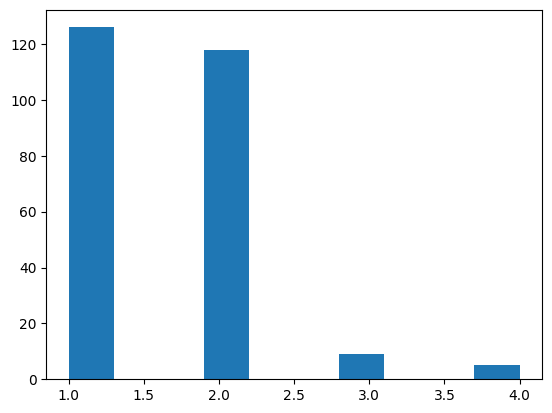

In [8]:
plt.hist(result)
plt.show()